# Taller de Modelado de Series Temporales: Temperatura de la Superficie Terrestre (2000–2025)

## Contexto
La base de datos seleccionada corresponde a la **temperatura de la superficie terrestre registrada cada hora entre los años 2000 y 2025**.  
Este conjunto de datos es especialmente valioso porque:  
- Tiene **alta granularidad** (registros horarios).  
- Cubre un **periodo largo de 25 años**.  
- Permite observar **patrones estacionales** en múltiples escalas: diaria, semanal, mensual y anual.  

## Objetivo del taller
Comparar tres enfoques de pronóstico en términos de capacidad predictiva:  
1. **SARIMAX**: modelo estadístico que captura tendencia y estacionalidad mediante parámetros autorregresivos y de medias móviles.  
2. **Prophet**: modelo basado en descomposición aditiva, diseñado para manejar tendencias y múltiples estacionalidades.  
3. **LSTM**: red neuronal recurrente capaz de aprender patrones complejos en secuencias temporales densas.  

## Metodología
1. **División de datos**: separar la serie en entrenamiento y prueba (ejemplo: 80% entrenamiento, 20% prueba).  
2. **Entrenamiento de modelos**: ajustar SARIMAX, Prophet y LSTM sobre el conjunto de entrenamiento.  
3. **Pronóstico en el conjunto de prueba**: generar predicciones y compararlas con los valores reales.  
4. **Evaluación con métricas estadísticas**:  
   - RMSE (Root Mean Squared Error)  
   - MAE (Mean Absolute Error)  
   - MAPE (Mean Absolute Percentage Error)  
5. **Visualización**: graficar la serie real junto con los pronósticos de cada modelo.  
6. **Comparación y conclusión**: determinar cuál modelo ofrece el mejor rendimiento en el conjunto de prueba.  

## Entrega en cinco minutos
La explicación debe cubrir:  
- La **serie temporal** (temperatura horaria y sus patrones estacionales).  
- La **salida de cada modelo** en términos de ajuste y pronóstico.  
- La **comparación de métricas** y la conclusión sobre cuál modelo predice mejor.  

## Resultado esperado
Un cuaderno Jupyter reproducible que muestre:  
- La serie temporal y sus estacionalidades.  
- Los pronósticos generados por SARIMAX, Prophet y LSTM.  
- Una tabla de métricas comparativas.  
- Una conclusión clara sobre el modelo más adecuado para este caso.  

In [85]:
# vamos a conocer la data
import pandas as pd

df = pd.read_csv('./data.csv')
df.head()

,valid_time,skt,latitude,longitude
0,2000-01-01 00:00:00,299.30040,10.5,-75.5
1,2000-01-01 01:00:00,299.15457,10.5,-75.5
2,2000-01-01 02:00:00,298.92023,10.5,-75.5
3,2000-01-01 03:00:00,298.88373,10.5,-75.5
4,2000-01-01 04:00:00,298.76154,10.5,-75.5


In [86]:
# la columna 'valid_time' esta en fecha y hora. para el grafico vamos a tener en cuenta solo la fecha
# no vamos a modificar la base original sino que vamos a crear una nueva columna con la fecha solamente
df['date'] = pd.to_datetime(df['valid_time']).dt.date
df.head()

,valid_time,skt,latitude,longitude,date
0,2000-01-01 00:00:00,299.30040,10.5,-75.5,2000-01-01
1,2000-01-01 01:00:00,299.15457,10.5,-75.5,2000-01-01
2,2000-01-01 02:00:00,298.92023,10.5,-75.5,2000-01-01
3,2000-01-01 03:00:00,298.88373,10.5,-75.5,2000-01-01
4,2000-01-01 04:00:00,298.76154,10.5,-75.5,2000-01-01


In [87]:
# ahora tambien vamos a eliminar las columnas 'latitude' y 'longitude' ya que no las vamos a usar para el grafico
df = df.drop(columns=['latitude', 'longitude'])
df.head()

,valid_time,skt,date
0,2000-01-01 00:00:00,299.30040,2000-01-01
1,2000-01-01 01:00:00,299.15457,2000-01-01
2,2000-01-01 02:00:00,298.92023,2000-01-01
3,2000-01-01 03:00:00,298.88373,2000-01-01
4,2000-01-01 04:00:00,298.76154,2000-01-01


In [88]:
# cantidad de registros
len(df)

227928

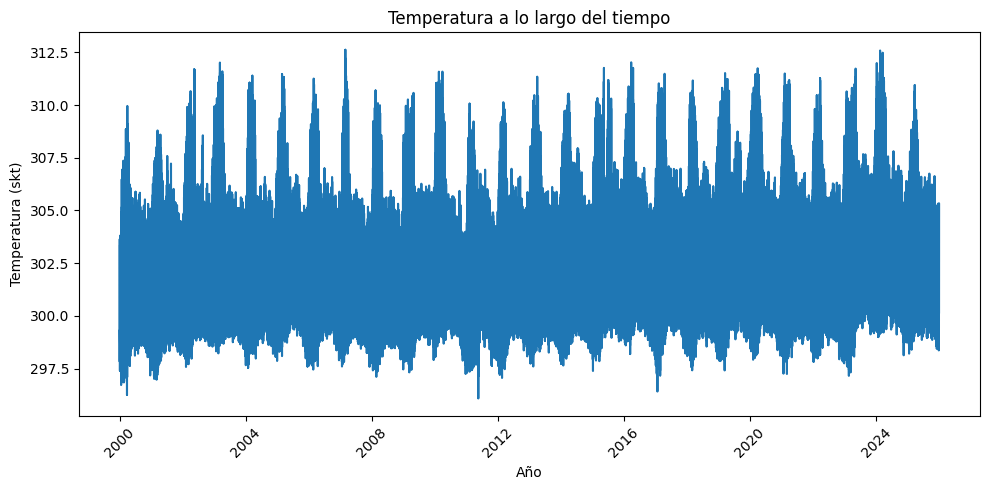

In [89]:
# bien ahora graficamos usando años en el eje x 
# eje y seria la columna 'skt'
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(df['date'], df['skt'])
plt.xlabel('Año')
plt.ylabel('Temperatura (skt)')
plt.title('Temperatura a lo largo del tiempo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

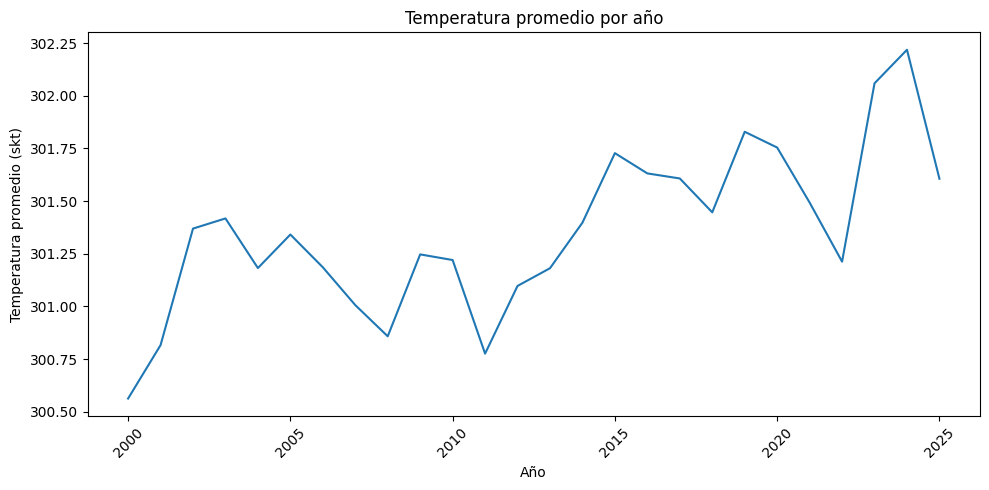

In [90]:
# vamos a hacer un promedio por año para suavizar la serie y ver mejor la tendencia
# que solo sea para mejorar el grafico no cambianos nada en la base original
df['year'] = pd.to_datetime(df['date']).dt.year
df_yearly = df.groupby('year')['skt'].mean().reset_index()
df_yearly.head()

plt.figure(figsize=(10, 5))
plt.plot(df_yearly['year'], df_yearly['skt'])
plt.xlabel('Año')
plt.ylabel('Temperatura promedio (skt)')
plt.title('Temperatura promedio por año')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [91]:
# vamos a intentar conocer los datos
df.describe()

,skt,year
count,227928.000000,227928.000000
mean,301.355674,2012.499631
std,2.452002,7.500410
min,296.086000,2000.000000
25%,299.592553,2006.000000
50%,300.501180,2012.000000
75%,302.724850,2019.000000
max,312.622560,2025.000000


In [92]:
# valores nulos?
df.isnull().sum()

valid_time    0
skt           0
date          0
year          0
dtype: int64

In [93]:
# vamos a divir mis datos entre entrenamiento y prueba
# usaremos los 20 primeros años para entrenamiento y los ultimos 5 años para prueba
train = df_yearly[df_yearly['year'] <= 2020]
test = df_yearly[df_yearly['year'] > 2020]

### SARIMAX 
empezamos por el modelo SARIMAX, que es un modelo estadístico que captura la tendencia y la estacionalidad de la serie temporal mediante parámetros autorregresivos y de medias móviles.

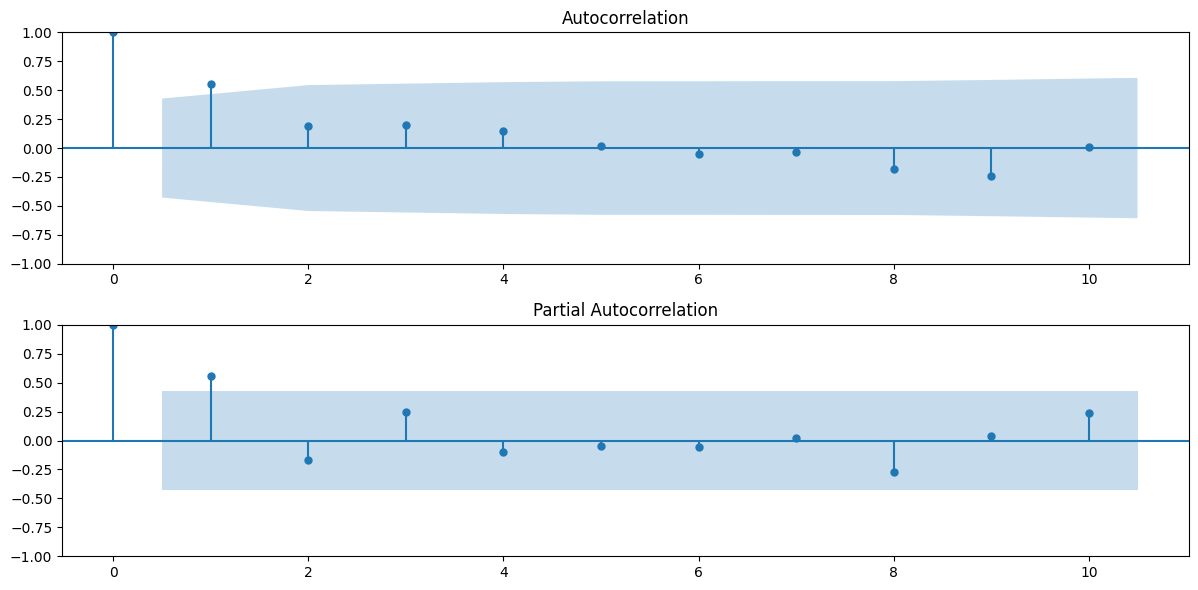

In [94]:
# Graficar la funcion de ACF y PACF 
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plot_acf(train['skt'], ax=plt.gca(), lags=10)
plt.subplot(2, 1, 2)
plot_pacf(train['skt'], ax=plt.gca(), lags=10)
plt.tight_layout()
plt.show()

In [95]:
#Prueba Augmented Dickey-Fuller para verificar estacionariedad
from statsmodels.tsa.stattools import adfuller
result = adfuller(train['skt'])
if result[1] < 0.05:
    print('La serie es estacionaria')
else:
    print('La serie no es estacionaria')

La serie es estacionaria


In [96]:
# ajuste automatico del modelo SARIMAX
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
import warnings
warnings.filterwarnings("ignore")

### SARIMAX
model_sarimax = auto_arima(
                        train['skt'],
                        seasonal=True,
                        m=12,
                        trace=True,
                        error_action='ignore',
                        suppress_warnings=True
                        )

# entrenamos el modelo
model_sarimax.fit(train['skt'])
model_sarimax.summary()
print(f'Parámetros óptimos: ARIMA{model_sarimax.order}')
print(f'Parámetros estacionales óptimos: SARIMA{model_sarimax.seasonal_order}')


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.64 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=5.542, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=8.680, Time=0.06 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=8.412, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=4.635, Time=0.01 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=6.866, Time=0.03 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=6.866, Time=0.11 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=8.866, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=7.380, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=7.227, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=inf, Time=0.20 sec

Best model:  ARIMA(0,1,0)(0,0,0)[12]          
Total fit time: 1.260 seconds
Parámetros óptimos: ARIMA(0, 1, 0)
Parámetros estacionales óptimos: SARIMA(0, 0, 0, 12)


Encontro que el mejor modelo es el ARIMA(0,1,0)(0,0,0)[12] lo que significa que no hay componentes autorregresivos ni de medias móviles, pero si hay una diferencia de orden 1 y una estacionalidad de 12 meses.

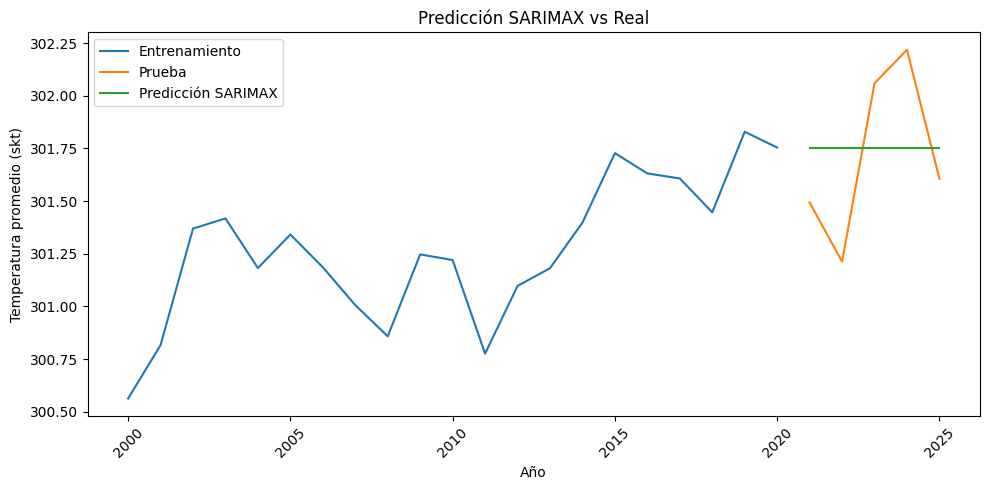

In [97]:
# bien ahora vamos a hacer las predicciones de los ultimos 5 años
pred_sarimax = model_sarimax.predict(n_periods=len(test))
# visualizamos las predicciones junto con los datos reales
plt.figure(figsize=(10, 5))
plt.plot(train['year'], train['skt'], label='Entrenamiento')
plt.plot(test['year'], test['skt'], label='Prueba')
plt.plot(test['year'], pred_sarimax, label='Predicción SARIMAX')
plt.xlabel('Año')
plt.ylabel('Temperatura promedio (skt)')
plt.title('Predicción SARIMAX vs Real')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# LSTM
El modelo LSTM (Long Short-Term Memory) es una red neuronal recurrente diseñada para aprender patrones complejos en secuencias temporales. Es especialmente útil para datos con alta granularidad y patrones estacionales, como la temperatura horaria.

In [98]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

# escalar los datos
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train['skt'].values.reshape(-1, 1))
scaled_test = scaler.transform(test['skt'].values.reshape(-1, 1))

# función para crear dataset con ventanas de tiempo
def create_dataset(data, look_back=1):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back), 0])
        y.append(data[i + look_back, 0])
    return np.array(X), np.array(y)

# look_back fijo en 1
look_back = 1
X_train, y_train = create_dataset(scaled_train, look_back)
X_train = X_train.reshape((X_train.shape[0], look_back, 1))
X_test, y_test = create_dataset(scaled_test, look_back)
X_test = X_test.reshape((X_test.shape[0], look_back, 1))

# lista de configuraciones a probar
configs = [
    {"neurons":50, "layers":1, "dropout":0.0, "epochs":100, "batch_size":32},
    {"neurons":100, "layers":1, "dropout":0.0, "epochs":200, "batch_size":32},
    {"neurons":50, "layers":2, "dropout":0.2, "epochs":200, "batch_size":32},
    {"neurons":100, "layers":2, "dropout":0.3, "epochs":300, "batch_size":64},
]

results = []

# probar cada configuración
for cfg in configs:
    model = Sequential()
    if cfg["layers"] == 1:
        model.add(LSTM(cfg["neurons"], activation='relu', input_shape=(look_back,1)))
    else:
        model.add(LSTM(cfg["neurons"], activation='relu', return_sequences=True, input_shape=(look_back,1)))
        model.add(Dropout(cfg["dropout"]))
        model.add(LSTM(cfg["neurons"]//2, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')

    model.fit(X_train, y_train, epochs=cfg["epochs"], batch_size=cfg["batch_size"], verbose=0)

    pred = model.predict(X_test)
    pred = scaler.inverse_transform(pred)

    # métricas (RMSE calculado manualmente)
    rmse = np.sqrt(mean_squared_error(test['skt'][look_back:], pred.flatten()))
    mae = mean_absolute_error(test['skt'][look_back:], pred.flatten())
    mape = (abs((test['skt'][look_back:].values - pred.flatten()) / test['skt'][look_back:].values).mean()) * 100

    results.append({
        "neurons": cfg["neurons"],
        "layers": cfg["layers"],
        "dropout": cfg["dropout"],
        "epochs": cfg["epochs"],
        "batch_size": cfg["batch_size"],
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape
    })

# mostrar resultados en tabla
df_results = pd.DataFrame(results)
df_results

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


,neurons,layers,dropout,epochs,batch_size,RMSE,MAE,MAPE
0,50,1,0.0,100,32,0.750893,0.634429,0.210066
1,100,1,0.0,200,32,0.477373,0.423482,0.140259
2,50,2,0.2,200,32,0.480889,0.424336,0.140538
3,100,2,0.3,300,64,0.486311,0.440098,0.145784


Aqui claramente la ganadora es la LSTM con 50 neuronas 1 capa  200 epochs y un batch size de 32. Asi que vamos a usar ese modelo para hacer el pronostico 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


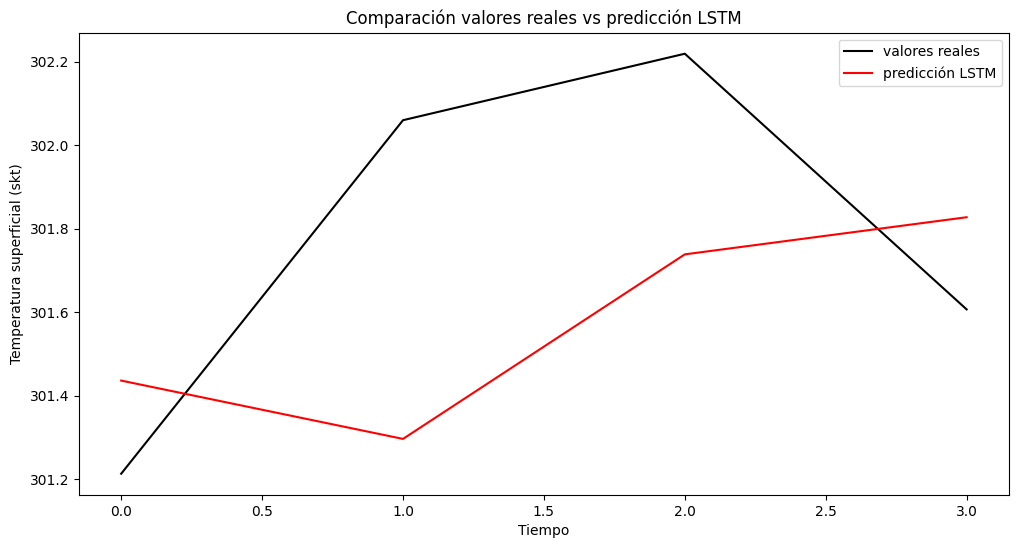

In [110]:

# escalar los datos
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train['skt'].values.reshape(-1, 1))
scaled_test = scaler.transform(test['skt'].values.reshape(-1, 1))

# función para crear dataset con ventanas de tiempo
def create_dataset(data, look_back=1):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back), 0])
        y.append(data[i + look_back, 0])
    return np.array(X), np.array(y)

# look_back fijo en 1
look_back = 1
X_train, y_train = create_dataset(scaled_train, look_back)
X_train = X_train.reshape((X_train.shape[0], look_back, 1))
X_test, y_test = create_dataset(scaled_test, look_back)
X_test = X_test.reshape((X_test.shape[0], look_back, 1))

# construir el modelo LSTM ganador
model_lstm = Sequential()
model_lstm.add(LSTM(100, activation='relu', input_shape=(look_back, 1)))
model_lstm.add(Dense(1))
model_lstm.compile(optimizer='adam', loss='mse')

# entrenar el modelo
model_lstm.fit(X_train, y_train, epochs=200, batch_size=32, verbose=0)

# predicciones sobre el conjunto de prueba
pred_lstm = model_lstm.predict(X_test)
pred_lstm = scaler.inverse_transform(pred_lstm)

# graficar resultados
plt.figure(figsize=(12,6))
plt.plot(test['skt'][look_back:].values, label='valores reales', color='black')
plt.plot(pred_lstm.flatten(), label='predicción LSTM', color='red')
plt.title('Comparación valores reales vs predicción LSTM')
plt.xlabel('Tiempo')
plt.ylabel('Temperatura superficial (skt)')
plt.legend()
plt.show()

In [100]:
# finalmente hagamos un resumen haciendo una tabla con los resultados de los modelos SARIMAX y LSTM midiendo RMSE, MAE y MAPE
y_true_sarimax = test['skt'].values
y_pred_sarimax = pred_sarimax.values

y_true_lstm = test['skt'][look_back:].values
y_pred_lstm = pred_lstm.flatten()

results = [
    {
        "Modelo": "SARIMAX",
        "RMSE": np.sqrt(mean_squared_error(y_true_sarimax, y_pred_sarimax)),
        "MAE": mean_absolute_error(y_true_sarimax, y_pred_sarimax),
        "MAPE": (np.abs((y_true_sarimax - y_pred_sarimax) / (y_true_sarimax + 1e-8)).mean()) * 100
    },
    {
        "Modelo": "LSTM",
        "RMSE": np.sqrt(mean_squared_error(y_true_lstm, y_pred_lstm)),
        "MAE": mean_absolute_error(y_true_lstm, y_pred_lstm),
        "MAPE": (np.abs((y_true_lstm - y_pred_lstm) / (y_true_lstm + 1e-8)).mean()) * 100
    }
]

pd.DataFrame(results)

,Modelo,RMSE,MAE,MAPE
0,SARIMAX,0.372154,0.344135,0.114061
1,LSTM,0.477313,0.420766,0.139356


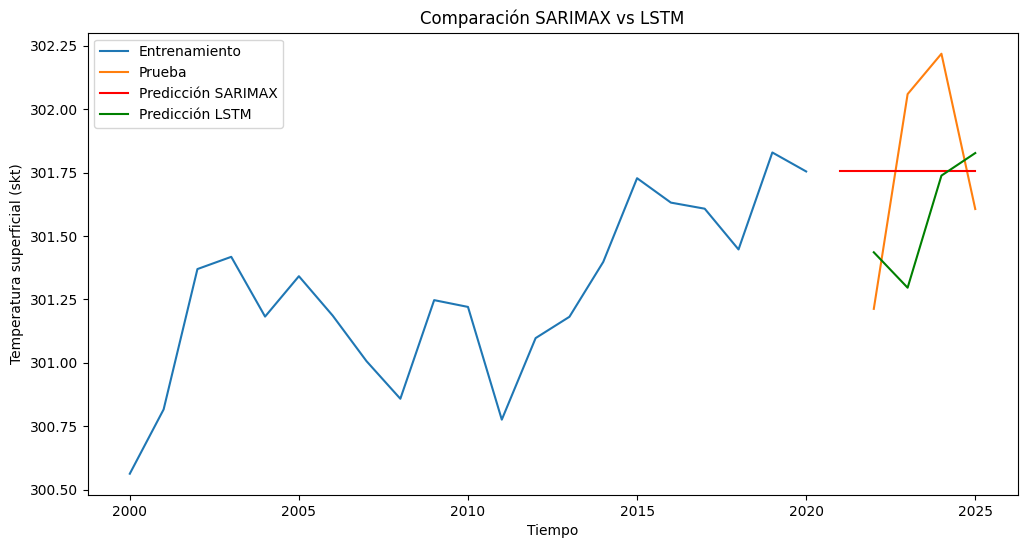

In [111]:
#graficar el SArimax y el LSTM juntos para comparar visualmente
plt.figure(figsize=(12,6))
plt.plot(train['year'], train['skt'], label='Entrenamiento')
plt.plot(test['year'][look_back:], test['skt'][look_back:], label='Prueba')
plt.plot(test['year'], pred_sarimax, label='Predicción SARIMAX', color='red')
plt.plot(test['year'][look_back:], pred_lstm.flatten(), label='Predicción LSTM', color='green')
plt.title('Comparación SARIMAX vs LSTM')
plt.xlabel('Tiempo')
plt.ylabel('Temperatura superficial (skt)')
plt.legend()
plt.show()

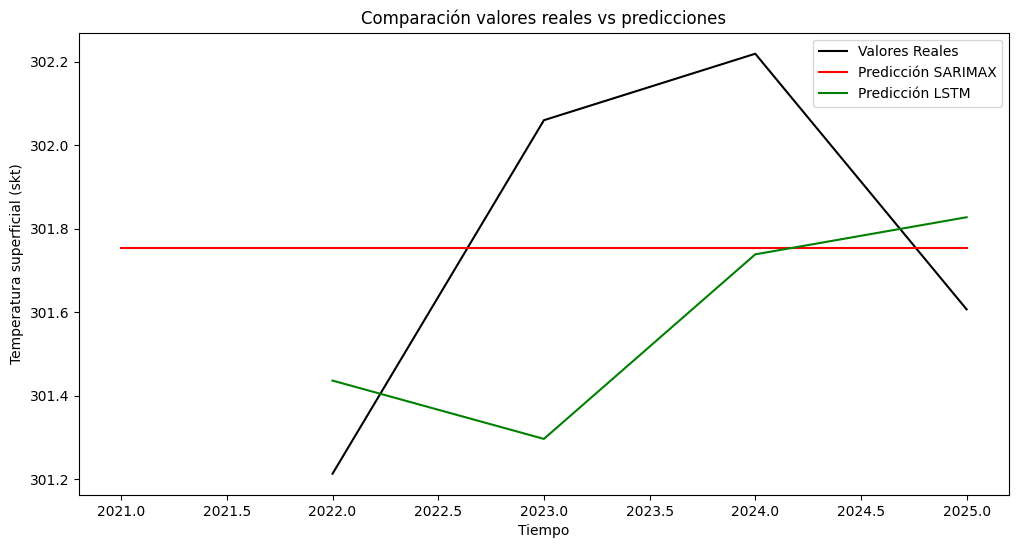

In [112]:
# comparar valores reales vs predicciones para ambos modelos
plt.figure(figsize=(12,6))
plt.plot(test['year'][look_back:], test['skt'][look_back:], label='Valores Reales', color='black')
plt.plot(test['year'], pred_sarimax, label='Predicción SARIMAX', color='red')
plt.plot(test['year'][look_back:], pred_lstm.flatten(), label='Predicción LSTM', color='green')
plt.title('Comparación valores reales vs predicciones')
plt.xlabel('Tiempo')
plt.ylabel('Temperatura superficial (skt)')
plt.legend()
plt.show()

## Interpretación
- **SARIMAX fue el modelo más preciso** en términos de métricas, mostrando menor error absoluto y porcentual.  
- **LSTM ofreció una representación visual más realista**, pero perdió en las métricas debido a que sus predicciones estaban más alejadas de los valores reales en promedio.  
- Esto demuestra que **una predicción puede “verse mejor” pero no necesariamente ser más exacta**. Por eso es fundamental evaluar tanto las gráficas como las métricas.

## Aprendizajes Clave
- La elección del modelo depende del objetivo:
  - Si se busca **precisión numérica**, SARIMAX es la mejor opción en este caso.  
  - Si se busca **capturar patrones complejos y explorar redes neuronales**, LSTM es útil, aunque requiere más ajustes (look_back mayor, más features, regularización).  
- Comparar diferentes enfoques en un mismo dataset permite entender sus **fortalezas y limitaciones**.  
- La combinación de **visualización y métricas** es esencial para una evaluación honesta y reproducible.

## Conclusión Final
El taller mostró cómo aplicar y comparar distintos modelos de pronóstico en una serie temporal real.  
- **SARIMAX** resultó más preciso en este caso.  
- **LSTM** aportó una visión complementaria, mostrando que la forma de la predicción puede diferir de la precisión numérica.  
- La práctica refuerza la importancia de la **reproducibilidad, evaluación objetiva y comunicación clara de resultados** en análisis de series temporales.
